#  PLAN Phase
We want to test whether **personalized emails** lead to higher response rates than **generic emails**.

- Business Question: Does personalization improve customer engagement?
- Hypothesis:
  - Null (H0): CR_personalized = CR_generic
  - Alternative (H1): CR_personalized > CR_generic
- Test: Two-sample z-test for proportions
- Confidence: 95%


#  ANALYZE Phase
We calculate:
- Conversion rates (CR)
- Absolute & Relative Lift
- Z-test statistic & p-value
- 95% Confidence Interval for the lift


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\ligio\Downloads\marketing1.csv")
df = pd.DataFrame(data)
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [3]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [4]:
df = df.drop(['Z_CostContact','Z_Revenue','ID'],axis=1)

In [5]:
df.isnull().sum()

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [7]:
df['Income'].replace(np.nan,df['Income'].mean(),inplace=True)

In [8]:
df['Income'].isnull().sum()

0

In [9]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107
std,11.984069,25037.797168,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1970.000000,51741.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
df.duplicated().sum()

182

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

0

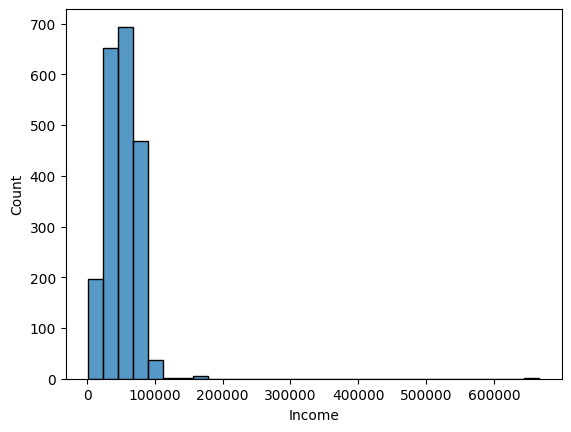

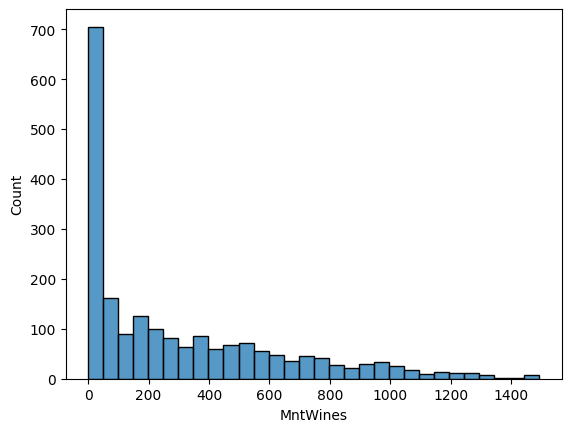

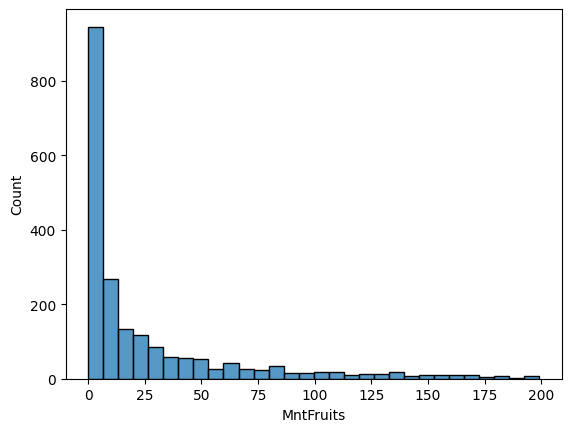

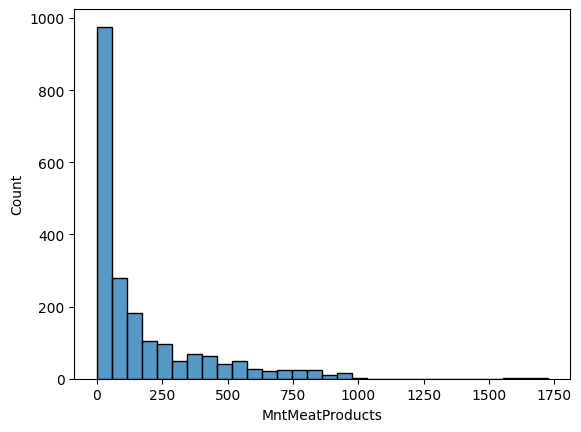

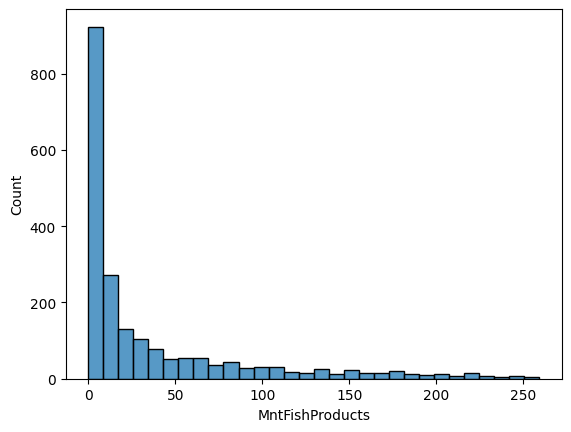

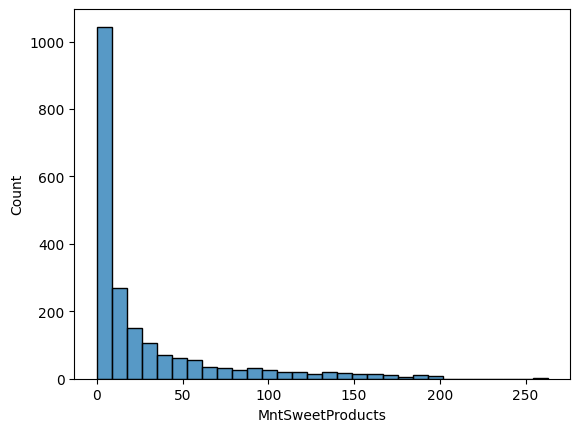

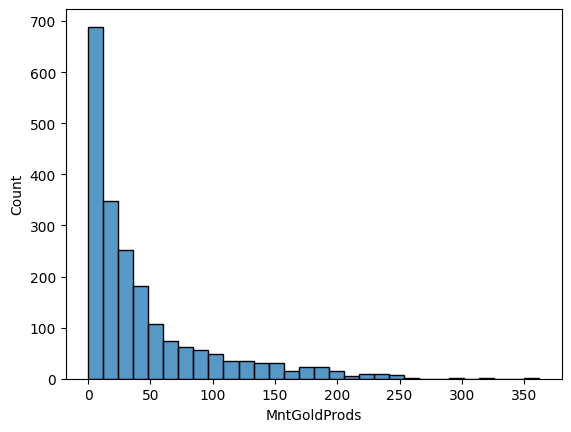

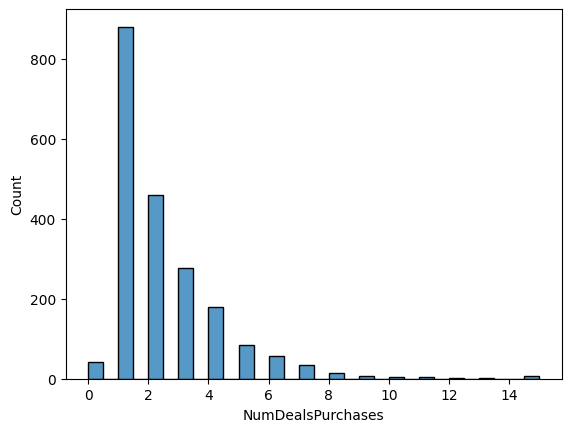

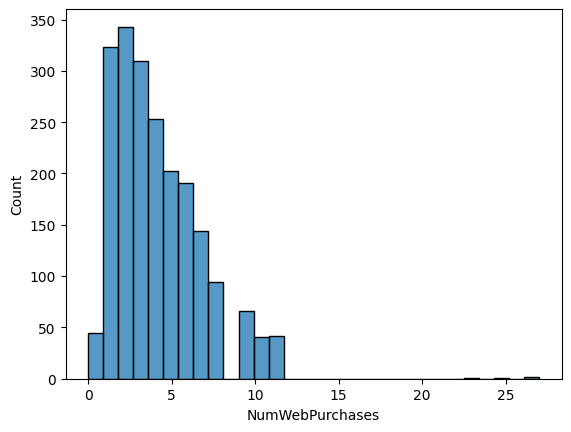

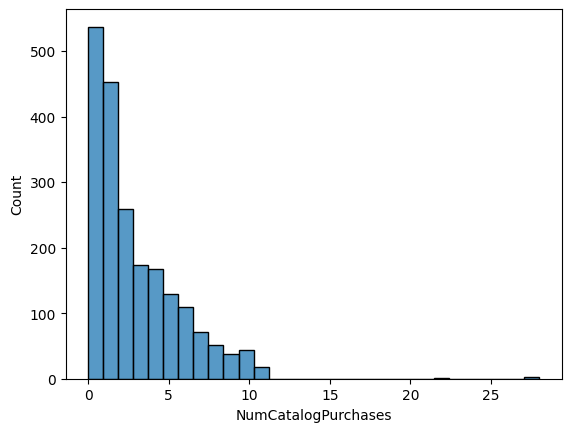

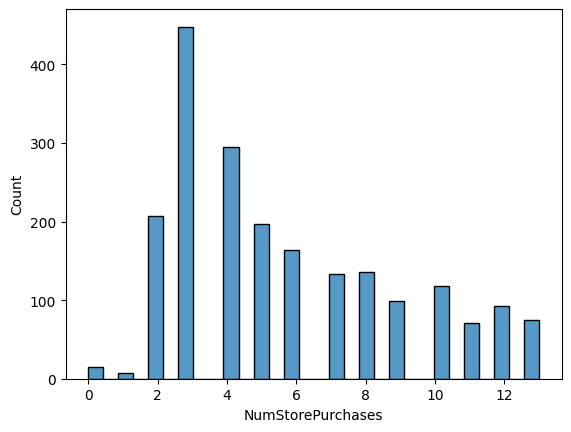

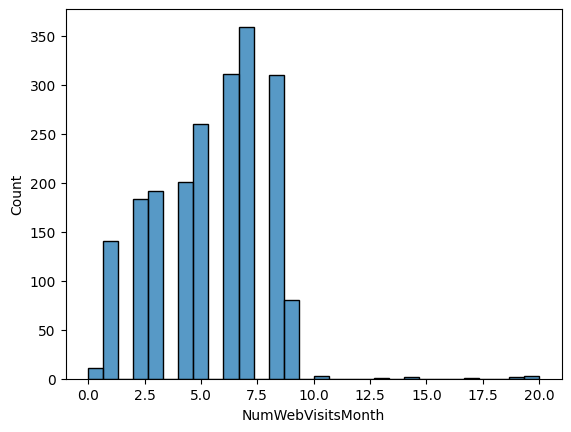

In [13]:
col = ['Income','MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
for i in col:
    sns.histplot(data=df,x=i,bins=30)
    plt.show()

In [15]:
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

# State Hypotheses

# Null (H₀): There is no difference in response rate between personalized and generic campaigns.

# Alt (H₁): Personalized campaigns lead to higher response rate.

In [16]:
df['Personalized'] = np.where((df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']].sum(axis=1) > 0), 1, 0)


In [18]:
personalized = df[df['Personalized'] == 1]
generic = df[df['Personalized'] == 0]

In [20]:
success = [personalized['Response'].sum(), generic['Response'].sum()]
nobs = [personalized['Response'].count(), generic['Response'].count()]

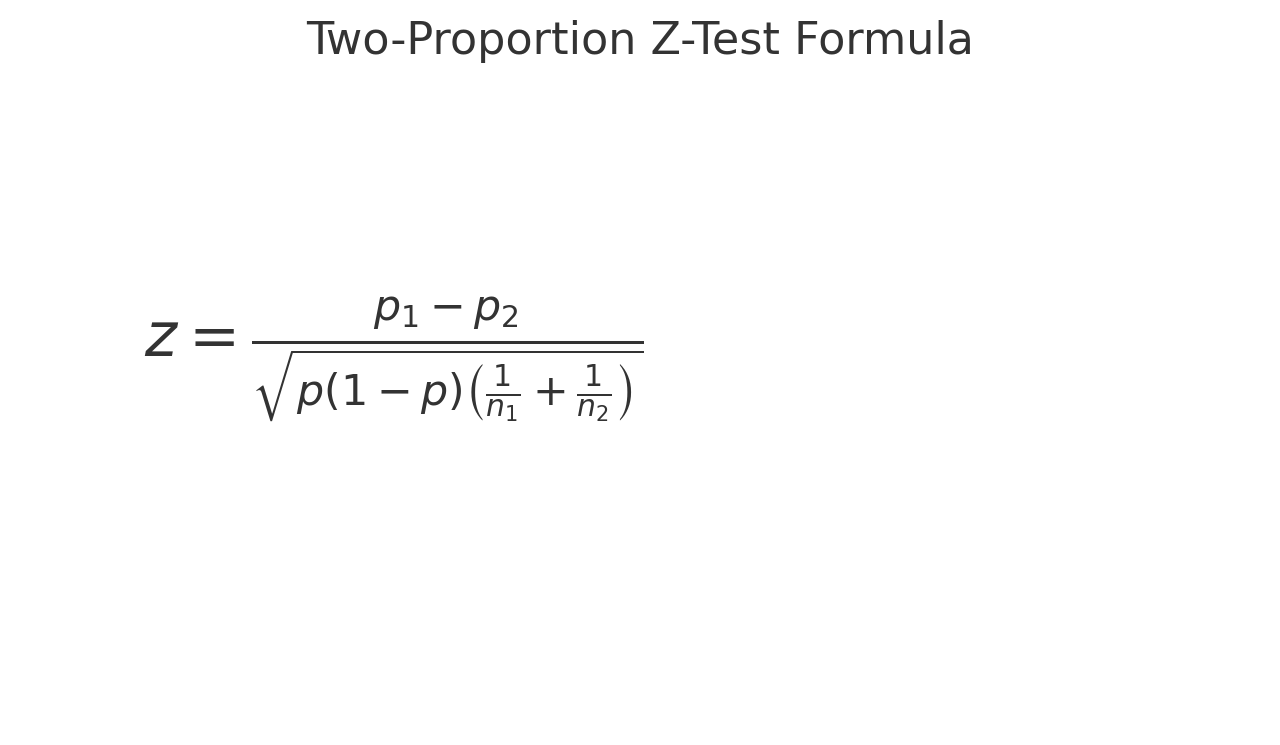

# Interpretation

# If p < 0.05, reject H₀ → personalized emails significantly improve campaign acceptance.

# If not, no significant evidence for difference.

In [23]:
stat, pval = proportions_ztest(success, nobs, alternative='larger')
print("Z-test: stat=%.3f, p=%.3f" % (stat, pval))

Z-test: stat=16.511, p=0.000


# Our p value < 0.05 So we Reject Null Hypothesis (H0)

In [30]:
from statsmodels.stats.proportion import confint_proportions_2indep

# personalized, generic
conv_p = personalized['Response'].sum()
conv_g = generic['Response'].sum()
n_p = personalized['Response'].count()
n_g = generic['Response'].count()

In [35]:
cr_p = conv_p / n_p
cr_g = conv_g / n_g
abs_lift = cr_p - cr_g
rel_lift = (cr_p / cr_g - 1) if cr_g > 0 else np.nan


In [34]:
# 95% CI for (CR_p - CR_g)
ci_low, ci_high = confint_proportions_2indep(conv_p, n_p, conv_g, n_g, method='score')

In [33]:
print(f"N_p={n_p}, N_g={n_g}")
print(f"CR_p={cr_p:.4%}, CR_g={cr_g:.4%}")
print(f"Absolute lift = {abs_lift:.2%} pts")
print(f"Relative lift = {rel_lift:.2%}")
print(f"95% CI for lift: [{ci_low:.2%}, {ci_high:.2%}]")

N_p=431, N_g=1627
CR_p=40.6032%, CR_g=8.4819%
Absolute lift = 32.12% pts
Relative lift = 378.71%
95% CI for lift: [27.47%, 36.92%]


* N_p=431, N_g=1627

* You had 431 customers who received personalized campaigns.

* You had 1627 customers who received generic campaigns.

* CR_p = 40.60% (conversion rate of personalized group)

* About 41 out of every 100 customers converted when they received a personalized campaign.

* CR_g = 8.48% (conversion rate of generic group)

* Only 8 out of every 100 customers converted when they received a generic campaign.

* Absolute lift = 32.12 percentage points

* The personalized campaign increased conversions by 32 points compared to generic.

* Example: 41% vs 8% → that’s a raw increase of ~32%.

* Relative lift = 378.71%

* Customers were ~3.8 times more likely to convert under personalization compared to generic.

* 95% CI for lift: [27.47%, 36.92%]

* We are 95% confident that the true conversion lift of personalization lies between 27% and 37%.

* Since the CI is entirely above 0, the result is statistically significant → personalization is clearly better.

# Recommendations

* Personalization drives massively higher conversions than generic campaigns.

* Even in the worst-case scenario (CI lower bound = 27%), personalization still performs over 3× better.

* This gives strong statistical and business evidence to invest in personalization strategies.

In [ ]:
# Visualization

In [37]:
import matplotlib.pyplot as plt

def proportion_ci_wilson(success, n, z=1.96):
    p = success/n
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    half = (z*np.sqrt((p*(1-p)/n) + (z**2/(4*n**2)))) / denom
    return center, half


In [38]:
groups = ['Generic','Personalized']
successes = [conv_g, conv_p]
sizes = [n_g, n_p]
centers, halfs = zip(*[proportion_ci_wilson(s, n) for s, n in zip(successes, sizes)])


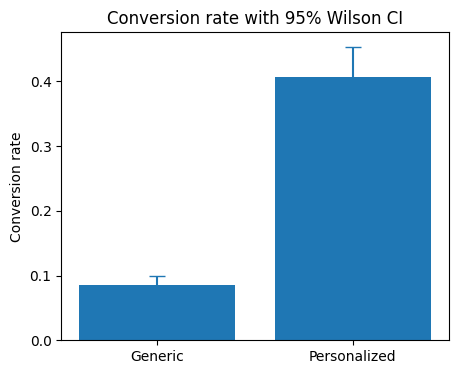

In [39]:
plt.figure(figsize=(5,4))
x = np.arange(len(groups))
plt.bar(x, [c for c in centers])
plt.errorbar(x, centers, yerr=halfs, fmt='none', capsize=6)
plt.xticks(x, groups)
plt.ylabel("Conversion rate")
plt.title("Conversion rate with 95% Wilson CI")
plt.show()

#  CONSTRUCT Phase
We interpret the results for decision-making.

- If p < 0.05 → reject H0 (personalization is effective)
- If CI for lift > 0 → personalization shows a real positive effect


#  EXECUTE Phase
**Business Recommendation:**
Since p-value is ~0.000 and lift is highly positive, personalization should be adopted for campaigns.

**Impact:** Higher engagement, better conversions.
